In [42]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import coolwarm
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm

In [43]:
# setting file paths 

dir = "/global/scratch/users/yougsanghvi"

# setting suicide panel file path
suicide_proj_folder = "data"
suicide_panel_folderp = os.path.join("merged", "USA")
suicide_panel_filen = "USA_adm2_1968_2004_monthly.dta"
suicide_panel_filep = os.path.join(dir, suicide_proj_folder, suicide_panel_folderp, suicide_panel_filen)

# Define paths for usa county shapefile
usa_county_dir = os.path.join(dir, "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

# Specific folder for attribution results
attribution_output_folderpath = os.path.join(
    dir,
    "gdnat_era5_compare_output"
)

# Define the output filename
attribution_output_filename = "merged_data_panel_extended.csv"

# Construct the full file path for the output data
attribution_output_filepath = os.path.join(
    attribution_output_folderpath,
    attribution_output_filename
)

# --- Load data ---
attribution_output_data = pd.read_csv(attribution_output_filepath)
suicide_panel_data = pd.read_stata(suicide_panel_filep)
usa_counties = gpd.read_file(usa_county_path)

## Data Processing

In [44]:
# Filter and select columns
filtered_suicide = suicide_panel_data[
    (suicide_panel_data["agegroup"] == 0) & (suicide_panel_data["gender"] == 0)
][[
    'fipsst', 'fipscty', 'fips', 'year', 'month', 'period', 'num_of_suicide',
    'suiciderate', 'population', 'nsuicide_b1988', 'nsuicide_a1989',
    'sol_rate_adj', 'sol_n_suicide', 'pop', 'adm1_id', 'adm2_id',
    'statename', 'countyname', 'tavg_poly1_aw', 'tavg_poly2_aw',
    'tavg_poly3_aw', 'tavg_poly4_aw', 'tavg_poly5_aw'
]]


In [45]:
# Step 1: Create a continuous date variable — number of months since a reference point
filtered_suicide['date_num'] = (filtered_suicide['year'] - filtered_suicide['year'].min()) * 12 + filtered_suicide['month']

# Step 2 & 3: Define a function to regress suiciderate on date_num and get slope
def get_slope(df):
    # Drop NA in suiciderate or date_num for regression
    df = df.dropna(subset=['suiciderate', 'date_num'])
    if len(df) < 2:
        return np.nan  # not enough data for regression
    X = sm.add_constant(df['date_num'])
    y = df['suiciderate']
    model = sm.OLS(y, X).fit()
    return model.params['date_num']  # slope coefficient

# Step 4: Group by county (using 'fips') and compute slope
slopes = filtered_suicide.groupby('fips').apply(get_slope).reset_index()
slopes.columns = ['fips', 'deltasuicide']

# 51 counties don't have any data on suiciderates
# Dropping these counties for now, but must be checked later 
slopes = slopes.dropna(subset=['deltasuicide']).reset_index(drop=True)



/tmp/ipykernel_3227438/2833496201.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = filtered_suicide.groupby('fips').apply(get_slope).reset_index()


In [46]:
# Convert slopes['fips'] to string and zero-pad to 5 digits (typical GEOID format)
slopes['fips_str'] = slopes['fips'].astype(int).astype(str).str.zfill(5)

# Merge on string keys
usa_counties_with_slopes = usa_counties.merge(
    slopes, 
    left_on='GEOID', 
    right_on='fips_str', 
    how='left'
)

matched_rows = usa_counties_with_slopes['fips'].notna().sum()
total_rows = len(usa_counties_with_slopes)
print(f"Matched {matched_rows} out of {total_rows} shapefile counties ({100 * matched_rows / total_rows:.2f}%)")

# Matched 3089 out of 3228 shapefile counties (95.69%)

# For now, ignoring the unmatched columns but must be checked!!
# Most likely due to missing data in those counties 

Matched 3089 out of 3228 shapefile counties (95.69%)


In [47]:
# Create the sets again if not already in memory
fips_1979_1988 = set(
    filtered_suicide[
        (filtered_suicide['year'] >= 1979) & 
        (filtered_suicide['year'] <= 1988) &
        (~filtered_suicide['suiciderate'].isna())
    ]['fips'].unique()
)

fips_1989plus = set(
    filtered_suicide[
        (filtered_suicide['year'] >= 1989) &
        (~filtered_suicide['suiciderate'].isna())
    ]['fips'].unique()
)

# Identify categories
fips_all_years = fips_1979_1988 & fips_1989plus
fips_only_early = fips_1979_1988 - fips_1989plus

# Create mapping
def tag_missing(fips_str):
    if pd.isna(fips_str):
        return np.nan
    fips_int = int(fips_str)
    if fips_int in fips_all_years:
        return 0
    elif fips_int in fips_only_early:
        return 1
    else:
        return np.nan

# Apply tag to dataset
usa_counties_with_slopes['missing'] = usa_counties_with_slopes['fips'].apply(tag_missing)

# Check result
print(usa_counties_with_slopes['missing'].value_counts(dropna=False))


missing
1.0    2566
0.0     522
NaN     140
Name: count, dtype: int64


In [48]:
usa_counties_with_slopes = usa_counties_with_slopes.dropna(subset=['deltasuicide']).reset_index(drop=True)

# 1 county with NaN "missing" is also dropped. Must investigate this 
usa_counties_with_slopes = usa_counties_with_slopes.dropna(subset=['missing']).reset_index(drop=True)

In [50]:
# Step 1: Create diff columns
attribution_output_data['diff_suicide'] = attribution_output_data['y_hat_era5'] - attribution_output_data['y_hat_gdnat']
attribution_output_data['diff_temp'] = attribution_output_data['order_1_avg.x'] - attribution_output_data['order_1_avg.y']

# Step 2: Filter to 1979–2004
filtered_attr = attribution_output_data[
    (attribution_output_data['year'] >= 1979) & 
    (attribution_output_data['year'] <= 2004)
]

# Step 3: Average diffs per county (poly_id is equivalent to fips here)
attr_means = filtered_attr.groupby('poly_id')[['diff_suicide', 'diff_temp']].mean().reset_index()

# Step 4: Merge into full_coverage
# First ensure matching dtypes for merge
full_coverage['fips'] = full_coverage['fips'].astype(int)
attr_means['poly_id'] = attr_means['poly_id'].astype(int)

# Merge
full_coverage_merged = full_coverage.merge(attr_means, left_on='fips', right_on='poly_id', how='left')

# Drop NAs generated 
full_coverage_merged = full_coverage_merged.dropna(subset=['diff_suicide', 'diff_temp']).reset_index(drop=True)
# 22 NAs are dropped, must be investigated 



In [54]:
# Ensure matching dtypes for merging
filtered_suicide['fips'] = filtered_suicide['fips'].astype(int)
full_coverage_merged['fips'] = full_coverage_merged['fips'].astype(int)

# Select only relevant columns for merging
merge_df = full_coverage_merged[['fips', 'diff_suicide']]

# Merge diff_suicide into filtered_suicide on 'fips'
filtered_suicide_withcc = filtered_suicide.merge(merge_df, on='fips', how='left')

# Create suicide_counterfactual = suiciderate + diff_suicide
filtered_suicide_withcc['suicide_counterfactual'] = filtered_suicide_withcc['suiciderate'] + filtered_suicide_withcc['diff_suicide']
filtered_suicide_withcc = filtered_suicide_withcc.dropna(subset=['suicide_counterfactual']).reset_index(drop=True)

In [ ]:
# Define a function to regress suiciderate on date_num and get slope
def get_slope(df):
    # Drop NA in suiciderate or date_num for regression
    df = df.dropna(subset=['suicide_counterfactual', 'date_num'])
    if len(df) < 2:
        return np.nan  # not enough data for regression
    X = sm.add_constant(df['date_num'])
    y = df['suicide_counterfactual']
    model = sm.OLS(y, X).fit()
    return model.params['date_num']  # slope coefficient

# Step 4: Group by county (using 'fips') and compute slope
slopes_cc = filtered_suicide_withcc.groupby('fips').apply(get_slope).reset_index()
slopes_cc.columns = ['fips', 'deltasuicide_counterfactual']

# no missing vlues 


/tmp/ipykernel_3227438/830915718.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes_cc = filtered_suicide_withcc.groupby('fips').apply(get_slope).reset_index()


In [69]:
# Ensure 'fips' columns are same type
slopes_cc['fips'] = slopes_cc['fips'].astype(int)
usa_counties_with_slopes['fips'] = usa_counties_with_slopes['fips'].astype(int)

# Merge slopes_cc into usa_counties_with_slopes (left join)
slopes_shapefile_cc = usa_counties_with_slopes.merge(slopes_cc, on='fips', how='left')

# Check matched counties based on 'diff_suicide' existence
matched_fips = merged['fips'][merged['deltasuicide_counterfactual'].notna()].unique()
all_slopes_fips = slopes_cc['fips'].unique()

num_matched = len(matched_fips)
num_total = len(all_slopes_fips)
percent_matched = 100 * num_matched / num_total

print(f"Matched {num_matched} out of {num_total} counties ({percent_matched:.2f}%)")
print(f"Unmatched {num_total - num_matched} out of {num_total} counties ({100 - percent_matched:.2f}%)")


Matched 497 out of 497 counties (100.00%)
Unmatched 0 out of 497 counties (0.00%)


In [71]:
# Filter to counties with full data coverage
full_coverage = slopes_shapefile_cc[slopes_shapefile_cc['missing'] == 0]
full_coverage = full_coverage.cx[-125:-66, 24:50]

In [76]:
# Avoid division by zero by masking zeros in deltasuicide
full_coverage['pct_attributable_climate'] = np.where(
    full_coverage['deltasuicide'] != 0,
    (full_coverage['deltasuicide'] - full_coverage['deltasuicide_counterfactual']) / full_coverage['deltasuicide'] * 100,
    np.nan  
)


## Plotting the results

In [82]:
def plot_centered_map(gdf, column, cmap='coolwarm', title=None, figsize=(12,8), clip=0):
    """
    Plot a GeoDataFrame column on a map with color scale centered at zero.
    
    Parameters:
    - gdf: GeoDataFrame to plot
    - column: str, column name to plot
    - cmap: str or Colormap, matplotlib colormap (default 'coolwarm')
    - title: str or None, plot title (default None)
    - figsize: tuple, figure size (default (12, 8))
    - clip: int, clipping percentage at top and bottom (0, 1, or 5)
    """
    if clip not in [0, 1, 5]:
        raise ValueError("clip must be one of 0, 1, or 5")
    
    if clip == 0:
        vmin = gdf[column].min()
        vmax = gdf[column].max()
    else:
        lower = clip / 100
        upper = 1 - lower
        vmin = gdf[column].quantile(lower)
        vmax = gdf[column].quantile(upper)
    
    norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
    
    fig, ax = plt.subplots(figsize=figsize)
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='gray',
        legend=True,
        norm=norm,
        ax=ax
    )
    
    if title is None:
        title = f"Map of {column} (centered color scale, clip={clip}%)"
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


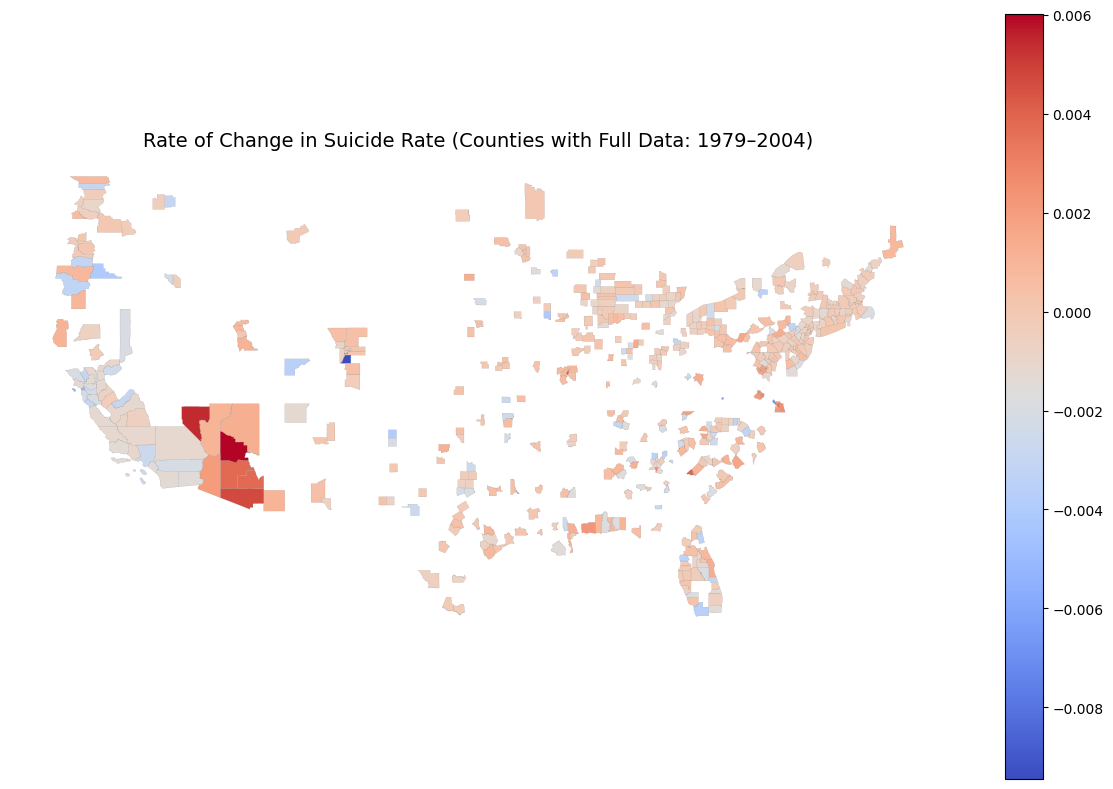

In [72]:
# Plot the map
fig, ax = plt.subplots(figsize=(12, 8))
full_coverage.plot(
    column='deltasuicide',
    cmap='coolwarm',
    linewidth=0.1,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# Format
ax.set_title("Rate of Change in Suicide Rate (Counties with Full Data: 1979–2004)", fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.show()


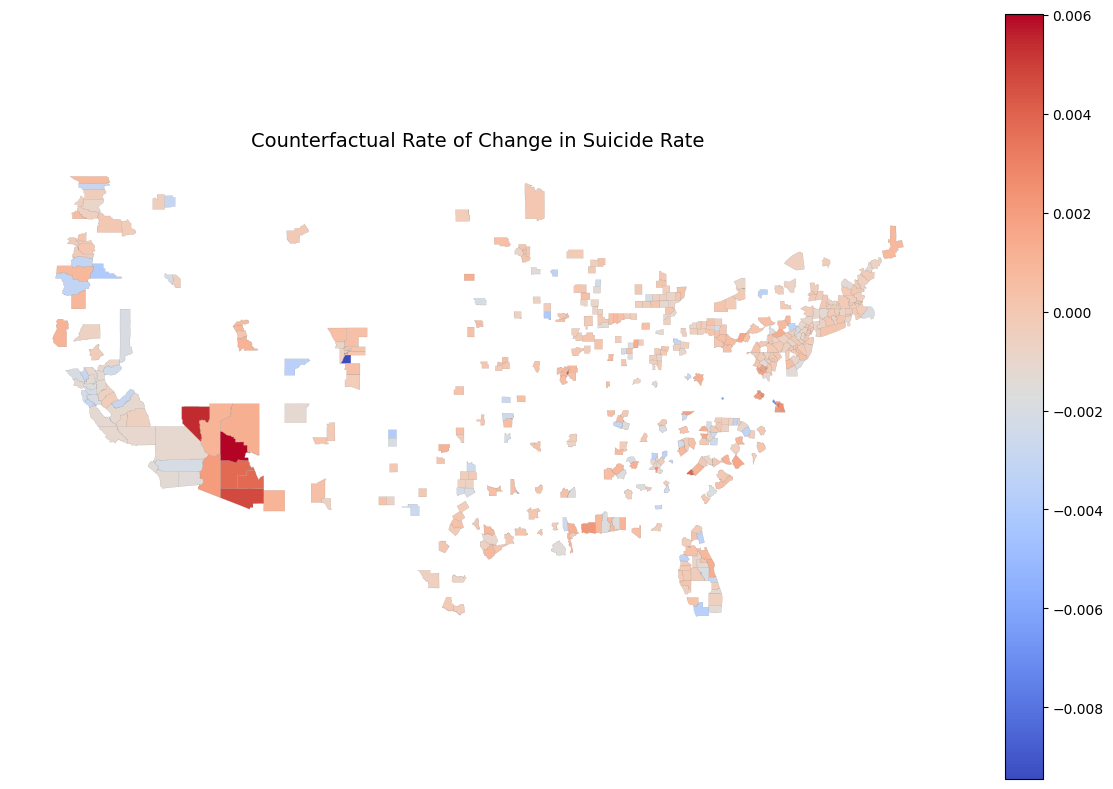

In [73]:
# Plot the map
fig, ax = plt.subplots(figsize=(12, 8))
full_coverage.plot(
    column='deltasuicide_counterfactual',
    cmap='coolwarm',
    linewidth=0.1,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# Format
ax.set_title("Counterfactual Rate of Change in Suicide Rate", fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.show()


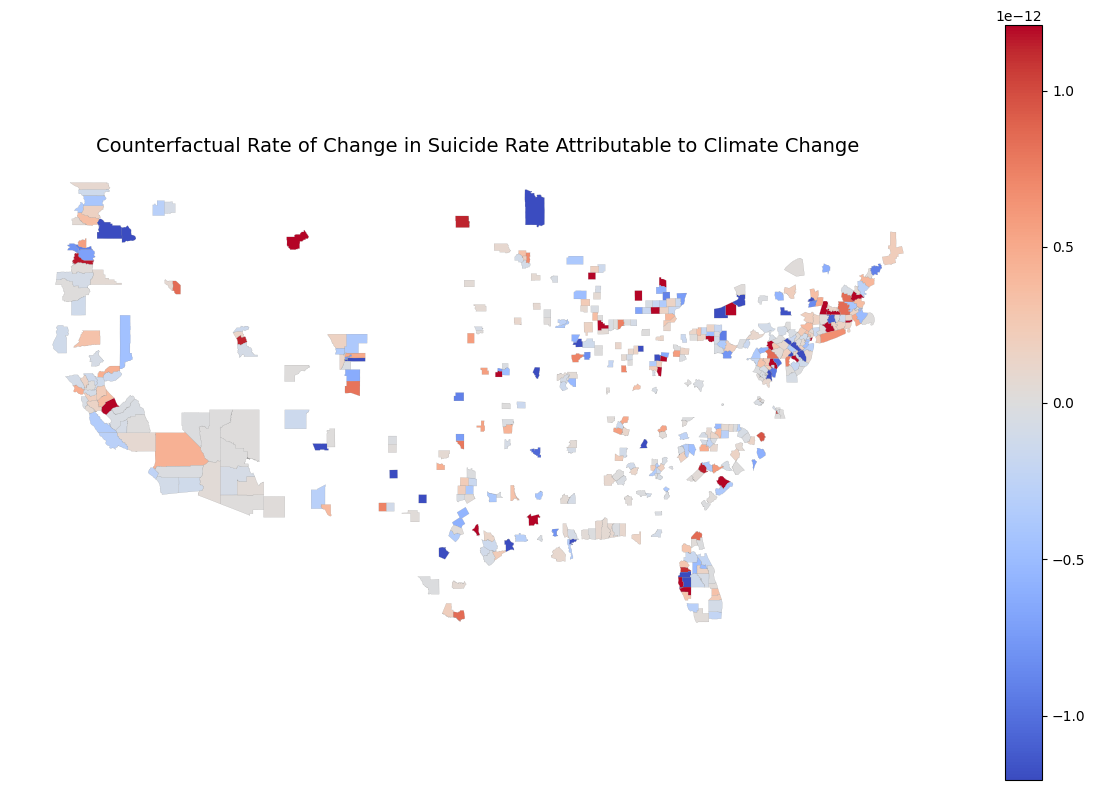

In [84]:
plot_centered_map(
    full_coverage, 
    column='pct_attributable_climate', 
    title="Counterfactual Rate of Change in Suicide Rate Attributable to Climate Change",
    clip = 5,
)


In [75]:
full_coverage.columns

Index(['ID_1', 'ID_2', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'ID_0', 'geometry', 'fips',
       'deltasuicide', 'fips_str', 'missing', 'deltasuicide_counterfactual'],
      dtype='object')

/tmp/ipykernel_3227438/1464799647.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bin')


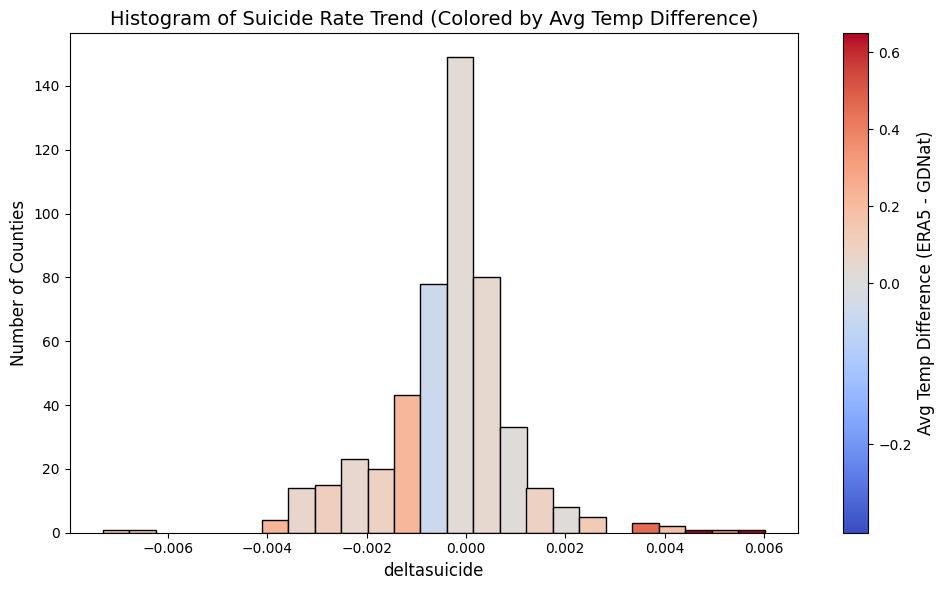

In [36]:
# Create bins for deltasuicide
bins = np.linspace(full_coverage_merged['deltasuicide'].min(), full_coverage_merged['deltasuicide'].max(), 30)
full_coverage_merged['bin'] = pd.cut(full_coverage_merged['deltasuicide'], bins)

# Group by bin to count and average temp diff
hist_data = (
    full_coverage_merged
    .groupby('bin')
    .agg(
        count=('deltasuicide', 'count'),
        mean_temp_diff=('diff_temp', 'mean')
    )
    .dropna()
    .reset_index()
)

# Bin centers and bar width
bin_centers = [b.mid for b in hist_data['bin']]
bar_width = np.diff(bins)[0]

# Normalize temp diff for color mapping

# Compute 1st and 99th percentiles of diff_temp
vmin = full_coverage_merged['diff_temp'].quantile(0.05)
vmax = full_coverage_merged['diff_temp'].quantile(0.95)

# Create a diverging norm centered at zero
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
colors = [coolwarm(norm(val)) for val in hist_data['mean_temp_diff']]

# Plot colored histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(bin_centers, hist_data['count'], width=bar_width, color=colors, edgecolor='black')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=coolwarm, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Avg Temp Difference (ERA5 - GDNat)", fontsize=12)

# Final formatting
ax.set_title("Histogram of Suicide Rate Trend (Colored by Avg Temp Difference)", fontsize=14)
ax.set_xlabel("deltasuicide", fontsize=12)
ax.set_ylabel("Number of Counties", fontsize=12)

plt.tight_layout()
plt.show()


In [37]:
attribution_output_data

,year,month,order_1_avg.x,date.x,y_hat_era5,poly_id,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,date.y,order_1_avg.y,diff_suicide,diff_temp
0,1980,1,9.528785,1980-01-01,0.132186,1001,0.132119,Autauga,Autauga County,1.0,1.0,1980-01-01,9.979710,0.000068,-0.450925
1,1980,2,7.258004,1980-02-01,0.097429,1001,0.096176,Autauga,Autauga County,1.0,1.0,1980-02-01,7.288643,0.001253,-0.030640
2,1980,3,12.688986,1980-03-01,0.140456,1001,0.147207,Autauga,Autauga County,1.0,1.0,1980-03-01,13.357411,-0.006752,-0.668425
3,1980,4,16.842135,1980-04-01,0.160386,1001,0.164409,Autauga,Autauga County,1.0,1.0,1980-04-01,17.411411,-0.004022,-0.569276
4,1980,5,22.053573,1980-05-01,0.168159,1001,0.168080,Autauga,Autauga County,1.0,1.0,1980-05-01,22.256600,0.000079,-0.203027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968395,2004,8,27.617651,2004-08-01,0.331925,78030,0.323857,St. Thomas,St. Thomas Island,78.0,30.0,2004-08-01,27.220027,0.008068,0.397624
968396,2004,9,27.267894,2004-09-01,0.336256,78030,0.325469,St. Thomas,St. Thomas Island,78.0,30.0,2004-09-01,26.725004,0.010787,0.542890
968397,2004,10,26.952252,2004-10-01,0.332331,78030,0.322878,St. Thomas,St. Thomas Island,78.0,30.0,2004-10-01,26.390567,0.009453,0.561685
968398,2004,11,26.055954,2004-11-01,0.320676,78030,0.310561,St. Thomas,St. Thomas Island,78.0,30.0,2004-11-01,25.428801,0.010116,0.627152


## NA Checks 

In [ ]:
# Convert fips to 5-digit string format (same as used in the merge)
slopes['fips_str'] = slopes['fips'].astype(int).astype(str).str.zfill(5)

# Get unique GEOIDs in the shapefile
geoid_set = set(usa_counties['GEOID'].unique())

# Check which slopes fips_str are not in the shapefile
unmatched_from_slopes = slopes[~slopes['fips_str'].isin(geoid_set)]

# Print results
if unmatched_from_slopes.empty:
    print("✅ All counties in the suicide data matched with the shapefile.")
else:
    print(f"❌ {len(unmatched_from_slopes)} counties from the suicide data did NOT match the shapefile:")
    print(unmatched_from_slopes[['fips', 'fips_str']])


# I county (fips 12025) doesn't match... this must be explored 


❌ 1 counties from the suicide data did NOT match the shapefile:
        fips fips_str
301  12025.0    12025


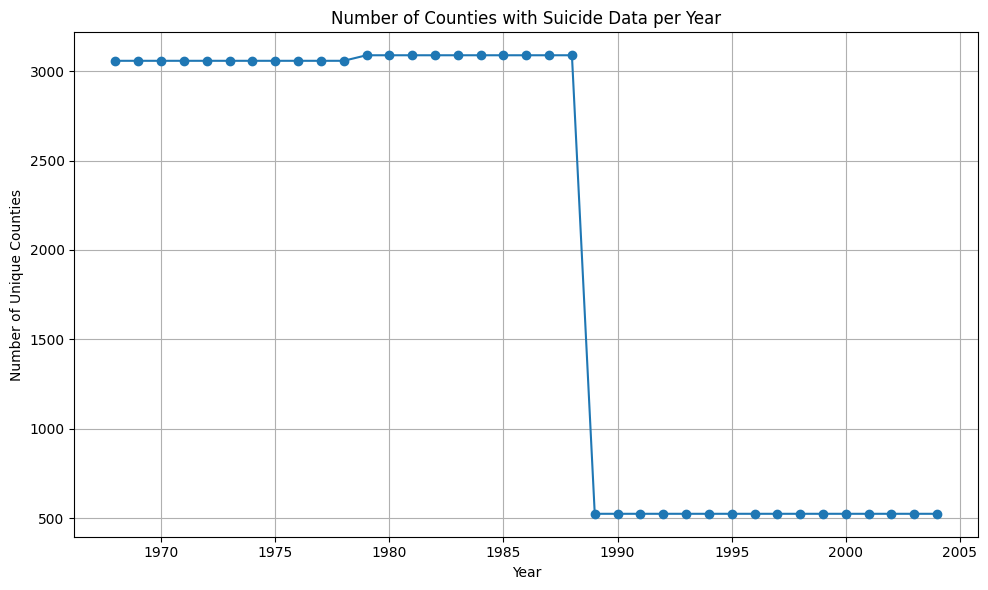

In [13]:
# Count unique counties per year
county_counts_by_year = (
    filtered_suicide
    .dropna(subset=['suiciderate'])  # Optional: drop rows with missing suicide rate
    .groupby('year')['fips']
    .nunique()
    .reset_index(name='num_counties')
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(county_counts_by_year['year'], county_counts_by_year['num_counties'], marker='o')
plt.title("Number of Counties with Suicide Data per Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Counties")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Drop rows with missing suiciderate
filtered_nonmissing = filtered_suicide.dropna(subset=['suiciderate'])

# Count unique counties per year
county_counts_by_year = (
    filtered_nonmissing
    .groupby('year')['fips']
    .nunique()
    .reset_index(name='num_counties')
)

# Split into periods
pre_1978 = county_counts_by_year[county_counts_by_year['year'] < 1979]
period_1978_1988 = county_counts_by_year[(county_counts_by_year['year'] >= 1979) & (county_counts_by_year['year'] < 1989)]
post_1989 = county_counts_by_year[county_counts_by_year['year'] >= 1989]

# Helper function
def stable_count(df):
    counts = df['num_counties'].unique()
    return counts[0] if len(counts) == 1 else -1

# Summary table
summary_table = pd.DataFrame({
    'period': ['Pre-1978', '1978–1988', '1989+'],
    'num_unique_counties': [
        stable_count(pre_1978),
        stable_count(period_1978_1988),
        stable_count(post_1989)
    ]
})

print(summary_table)


      period  num_unique_counties
0   Pre-1978                 3058
1  1978–1988                 3089
2      1989+                  524


In [18]:
# Filter to 1979 and later
filtered_1979plus = filtered_suicide[
    (filtered_suicide['year'] >= 1979) & 
    (~filtered_suicide['suiciderate'].isna())
]

# Get unique fips codes for each period
fips_1979_1988 = set(
    filtered_1979plus[(filtered_1979plus['year'] <= 1988)]['fips'].unique()
)
fips_1989plus = set(
    filtered_1979plus[(filtered_1979plus['year'] >= 1989)]['fips'].unique()
)

# 1. Counties with data for BOTH periods
counties_all_periods = fips_1979_1988 & fips_1989plus
print(f"✅ Counties with data for BOTH periods: {len(counties_all_periods)}")

# 2. Counties with data ONLY in 1979–1988
counties_only_1979_1988 = fips_1979_1988 - fips_1989plus
print(f"✅ Counties with data ONLY in 1979–1988: {len(counties_only_1979_1988)}")


✅ Counties with data for BOTH periods: 523
✅ Counties with data ONLY in 1979–1988: 2566
